In [1]:
import warnings

warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
import joblib, json

In [2]:
df = pd.read_csv("data/stroke_data.csv")
print("Shape:", df.shape)
print(df.head())


Shape: (40910, 11)
   sex   age  hypertension  heart_disease  ever_married  work_type  \
0  1.0  63.0             0              1             1          4   
1  1.0  42.0             0              1             1          4   
2  0.0  61.0             0              0             1          4   
3  1.0  41.0             1              0             1          3   
4  1.0  85.0             0              0             1          4   

   Residence_type  avg_glucose_level   bmi  smoking_status  stroke  
0               1             228.69  36.6               1       1  
1               0             105.92  32.5               0       1  
2               1             171.23  34.4               1       1  
3               0             174.12  24.0               0       1  
4               1             186.21  29.0               1       1  


In [3]:
cols_to_drop = ["heart_disease", "hypertension", "ever_married"]
df = df.drop(columns=cols_to_drop, errors="ignore")
print("Remaining columns:", df.columns.tolist())

Remaining columns: ['sex', 'age', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']


In [4]:
X = df.drop("stroke", axis=1)
y = df["stroke"]

In [5]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("\nNumeric features:", num_cols)
print("Categorical features:", cat_cols)


Numeric features: ['sex', 'age', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status']
Categorical features: []


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("\nTrain size:", X_train.shape, "| Test size:", X_test.shape)


Train size: (32728, 7) | Test size: (8182, 7)


In [7]:
num_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]
)

# Categorical pipeline
cat_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]
)

# Combine
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_cols),
        ("cat", cat_transformer, cat_cols),
    ]
)


In [8]:
rf = RandomForestClassifier(
    random_state=42, n_estimators=200, max_depth=12, class_weight="balanced_subsample"
)

pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", rf),
    ]
)


In [9]:
param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [10, 12, 15],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2],
}

grid = GridSearchCV(pipe, param_grid, cv=5, n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

print("\nBest parameters:", grid.best_params_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best parameters: {'classifier__max_depth': 15, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}



Accuracy: 0.9699340014666341
              precision    recall  f1-score   support

           0       0.98      0.95      0.97      4090
           1       0.96      0.99      0.97      4092

    accuracy                           0.97      8182
   macro avg       0.97      0.97      0.97      8182
weighted avg       0.97      0.97      0.97      8182

ROC-AUC: 0.9958522443458164


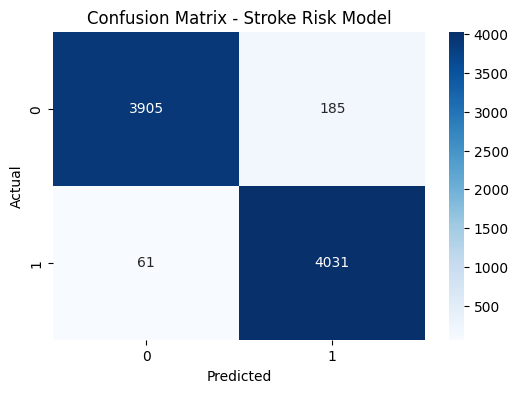

In [10]:
y_pred = grid.predict(X_test)
y_proba = grid.predict_proba(X_test)[:, 1]

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Stroke Risk Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [11]:
scores = cross_val_score(grid.best_estimator_, X, y, cv=5, scoring="roc_auc")
print("\nCross-val ROC-AUC scores:", np.round(scores, 3))
print("Mean AUC:", scores.mean(), "Std:", scores.std())



Cross-val ROC-AUC scores: [0.993 0.995 0.992 0.995 0.998]
Mean AUC: 0.9943842478734819 Std: 0.0019867134809278117
